In [35]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates


In [21]:
df = pd.read_csv(r"C:\Users\salma\Downloads\Source_2_Fixtures_2026_Chicago_Stars_All_Competitions.csv")
df.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,Poss,Attendance,Captain,Formation,Opp Formation,Referee,Match Report,Notes
0,2026-03-15,16:00 (01:00),NWSL,Regular Season,Sun,Away,L,0.0,4.0,Angel City FC,40.0,16813.0,Alyssa Naeher,4-2-3-1,4-3-1-2,Shawn Tehini,Match Report,NaN
1,2026-03-22,13:00 (20:00),NWSL,Regular Season,Sun,Away,W,2.0,1.0,Current,50.0,4192.0,Alyssa Naeher,4-2-3-1,4-3-3,Alex Billeter,Match Report,NaN
2,2026-03-25,19:00 (02:00),NWSL,Regular Season,Wed,Home,L,2.0,3.0,Orlando Pride,52.0,1821.0,Alyssa Naeher,4-2-3-1,4-2-3-1,Matthew Thompson,Match Report,NaN
3,2026-03-28,17:45 (02:45),NWSL,Regular Season,Sat,Away,L,0.0,2.0,SD Wave,41.0,12810.0,Alyssa Naeher,4-2-3-1,4-2-3-1,Servando Berna Rico,Match Report,NaN
4,2026-04-03,19:00 (03:00),NWSL,Regular Season,Fri,Away,L,0.0,1.0,Royals,39.0,10012.0,Kathrin Hendrich,4-2-3-1,4-2-3-1,Trevor Wiseman,Match Report,NaN


In [22]:
df.dtypes

Date                 str
Time                 str
Comp                 str
Round                str
Day                  str
Venue                str
Result               str
GF               float64
GA               float64
Opponent             str
Poss             float64
Attendance       float64
Captain              str
Formation            str
Opp Formation        str
Referee              str
Match Report         str
Notes            float64
dtype: object

In [23]:

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Convert numeric columns
float_cols = ["GF", "GA", "Poss", "Attendance", "Notes"]
for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

# Convert string columns
str_cols = [
    "Time",
    "Comp",
    "Round",
    "Day",
    "Venue",
    "Result",
    "Opponent",
    "Captain",
    "Formation",
    "Opp Formation",
    "Referee",
    "Match Report",
]
for col in str_cols:
    df[col] = df[col].astype("string")

# Check resulting column dtypes
print(df.dtypes)

Date             datetime64[us]
Time                     string
Comp                     string
Round                    string
Day                      string
Venue                    string
Result                   string
GF                      float64
GA                      float64
Opponent                 string
Poss                    float64
Attendance              float64
Captain                  string
Formation                string
Opp Formation            string
Referee                  string
Match Report             string
Notes                   float64
dtype: object


In [24]:
df.isna().sum()

Date              0
Time              0
Comp              0
Round             0
Day               0
Venue             0
Result            7
GF                7
GA                7
Opponent          0
Poss              7
Attendance        7
Captain           7
Formation         7
Opp Formation     7
Referee           7
Match Report      0
Notes            30
dtype: int64

In [25]:
df.shape

(30, 18)

# Win / Draw / Loss rate

In [26]:
# Calculate total counts and percentage rates
counts = df["Result"].value_counts()
rates = df["Result"].value_counts(normalize=True) * 100

# Combine into a structured Summary DataFrame
wdl_summary = pd.DataFrame(
    {"Count": counts, "Rate (%)": rates.round(2)}
).reindex(["W", "D", "L"], fill_value=0)

print(wdl_summary)

        Count  Rate (%)
Result                 
W           6     26.09
D           1      4.35
L          16     69.57


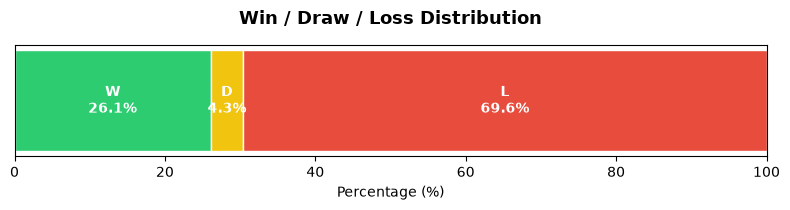

In [27]:

# Colors for W/D/L
colors = {"W": "#2ecc71", "D": "#f1c40f", "L": "#e74c3c"}

fig, ax = plt.subplots(figsize=(8, 2.2))

left = 0
for result in ["W", "D", "L"]:
    pct = wdl_summary.loc[result, "Rate (%)"]
    cnt = wdl_summary.loc[result, "Count"]
    ax.barh(
        y=0,
        width=pct,
        left=left,
        color=colors[result],
        edgecolor="white",
        height=0.6,
        label=f"{result} ({cnt})"
    )
    # Annotate inside the segment if it's wide enough
    if pct > 4:  # avoid clutter on tiny slices
        ax.text(
            left + pct / 2, 0,
            f"{result}\n{pct:.1f}%",
            ha="center", va="center",
            fontsize=10, fontweight="bold",
            color="white"
        )
    left += pct

# Clean up axes
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Percentage (%)")
ax.set_title("Win / Draw / Loss Distribution", fontsize=13, fontweight="bold", pad=15)

# Legend below the chart
"""
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    frameon=False
)"""

plt.tight_layout()
plt.show()

# Goals scored vs. Goals conceded

In [28]:
# Calculate goal metrics in Pandas
gf_total = df["GF"].sum()
ga_total = df["GA"].sum()
goal_diff = gf_total - ga_total

gf_avg = df["GF"].mean()
ga_avg = df["GA"].mean()

# Match-level differential
df["Goal_Diff"] = df["GF"] - df["GA"]

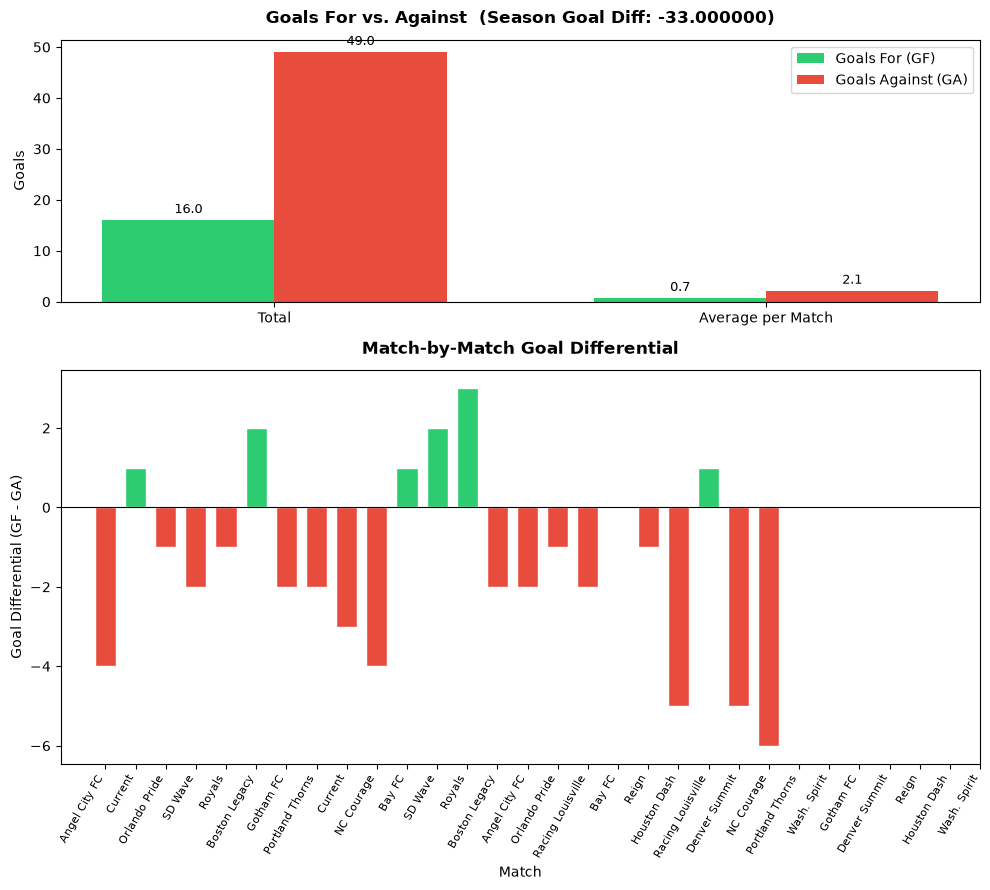

In [29]:

fig, axes = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={"height_ratios": [1, 1.5]})

# --- Plot 1: GF vs GA totals & averages ---
ax1 = axes[0]
categories = ["Total", "Average per Match"]
gf_vals = [gf_total, gf_avg]
ga_vals = [ga_total, ga_avg]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, gf_vals, width, label="Goals For (GF)", color="#2ecc71")
bars2 = ax1.bar(x + width/2, ga_vals, width, label="Goals Against (GA)", color="#e74c3c")

ax1.bar_label(bars1, fmt="%.1f", padding=3, fontsize=9)
ax1.bar_label(bars2, fmt="%.1f", padding=3, fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.set_ylabel("Goals")
ax1.set_title(f"Goals For vs. Against  (Season Goal Diff: {goal_diff:0f})",
              fontsize=12, fontweight="bold", pad=12)
ax1.legend()

# --- Plot 2: Match-level goal differential ---
ax2 = axes[1]
match_idx = np.arange(len(df))
colors = np.where(df["Goal_Diff"] >= 0, "#2ecc71", "#e74c3c")

ax2.bar(match_idx, df["Goal_Diff"], color=colors, edgecolor="white", width=0.7)
ax2.axhline(0, color="black", linewidth=0.8)

ax2.set_xlabel("Match")
ax2.set_ylabel("Goal Differential (GF - GA)")
ax2.set_title("Match-by-Match Goal Differential", fontsize=12, fontweight="bold", pad=12)

# Use opponent names as x-tick labels if available, else match number
if "Opponent" in df.columns:
    ax2.set_xticks(match_idx)
    ax2.set_xticklabels(df["Opponent"], rotation=60, ha="right", fontsize=8)
else:
    ax2.set_xticks(match_idx[::max(1, len(df)//15)])

plt.tight_layout()
plt.show()

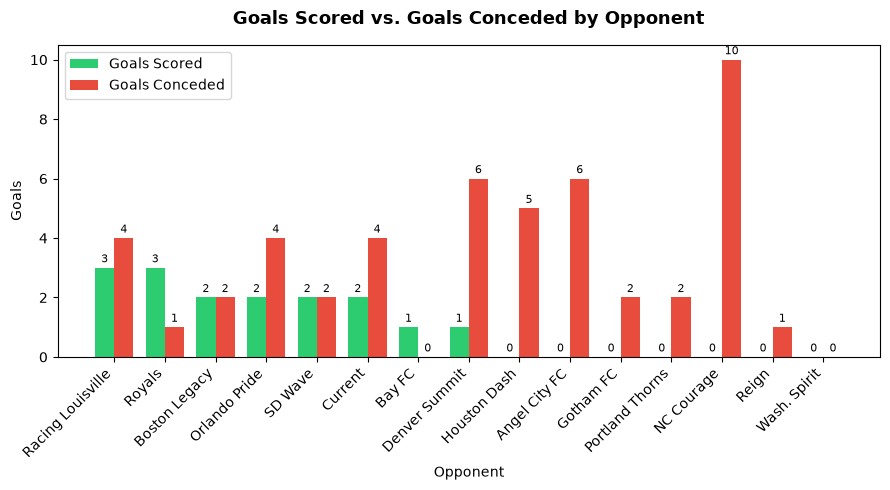

In [30]:
# Group by opponent, summing goals scored and conceded
goals_summary = df.groupby("Opponent")[["GF", "GA"]].sum()

# Sort opponents by total goals scored (optional, makes it easier to read)
goals_summary = goals_summary.sort_values("GF", ascending=False)

opponents = goals_summary.index
x = np.arange(len(opponents))
width = 0.38

fig, ax = plt.subplots(figsize=(max(8, len(opponents) * 0.6), 5))

bars1 = ax.bar(x - width/2, goals_summary["GF"], width,
                label="Goals Scored", color="#2ecc71")
bars2 = ax.bar(x + width/2, goals_summary["GA"], width,
                label="Goals Conceded", color="#e74c3c")

# Annotate bars with values
for bars in (bars1, bars2):
    ax.bar_label(bars, padding=2, fontsize=8)

ax.set_xlabel("Opponent")
ax.set_ylabel("Goals")
ax.set_title("Goals Scored vs. Goals Conceded by Opponent", fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(opponents, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

# Performance Analysis

In [31]:
# Calculate Points Per Match in Pandas
df["Points"] = df["Result"].map({"W": 3, "D": 1, "L": 0})

total_ppm = df["Points"].sum() / len(df)
ppm_by_venue = df.groupby("Venue")["Points"].mean()

In [32]:
ppm_by_venue

Venue
Away    0.428571
Home    1.444444
Name: Points, dtype: float64

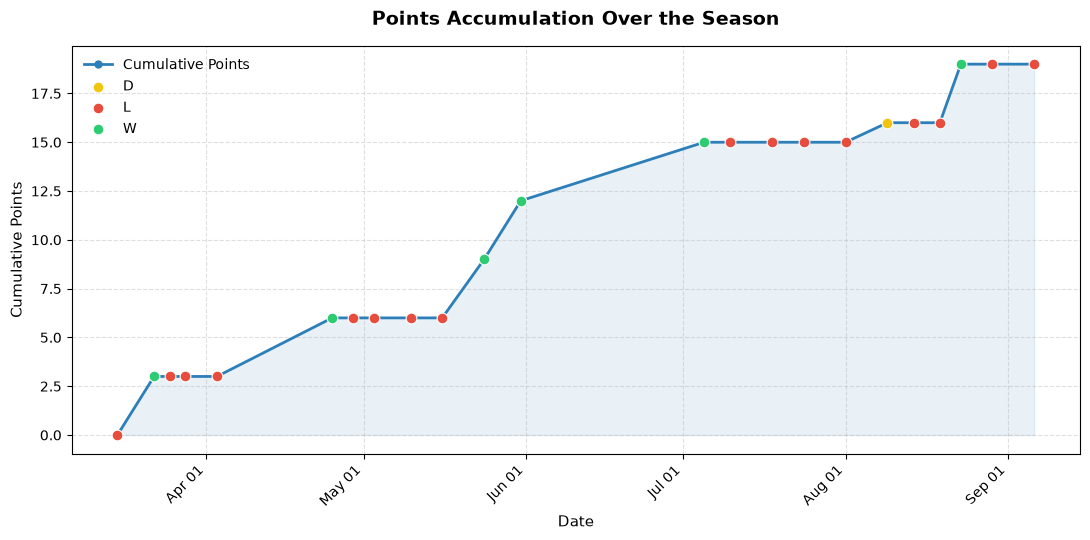

In [36]:


# Ensure Date is proper datetime and sorted
df = df.sort_values("Date")
df["Date"] = pd.to_datetime(df["Date"])

# Cumulative points (running total across the season)
df["Cumulative_Points"] = df["Points"].cumsum()

fig, ax = plt.subplots(figsize=(11, 5.5))

# Main line: cumulative points
ax.plot(df["Date"], df["Cumulative_Points"],
        marker="o", markersize=5, linewidth=2,
        color="#2c7fb8", label="Cumulative Points")

# Fill under the curve for visual weight
ax.fill_between(df["Date"], df["Cumulative_Points"], alpha=0.1, color="#2c7fb8")

# Color-code markers by result if available (W/D/L)
if "Result" in df.columns:
    color_map = {"W": "#2ecc71", "D": "#f1c40f", "L": "#e74c3c"}
    for result, group in df.groupby("Result"):
        ax.scatter(group["Date"], group["Cumulative_Points"],
                   color=color_map.get(result, "gray"), s=60, zorder=5,
                   label=f"{result}", edgecolor="white", linewidth=0.8)

# Format x-axis dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

# Labels, title, grid
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Cumulative Points", fontsize=11)
ax.set_title("Points Accumulation Over the Season", fontsize=14, fontweight="bold", pad=15)
ax.grid(True, linestyle="--", alpha=0.4)

# Annotate final total
final_date = df["Date"].iloc[-1]
final_points = df["Cumulative_Points"].iloc[-1]
ax.annotate(f"{final_points} pts",
            xy=(final_date, final_points),
            xytext=(10, 0), textcoords="offset points",
            fontsize=10, fontweight="bold", va="center")

ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

In [37]:
df["Rolling_PPM_5"] = df["Points"].rolling(5).mean()

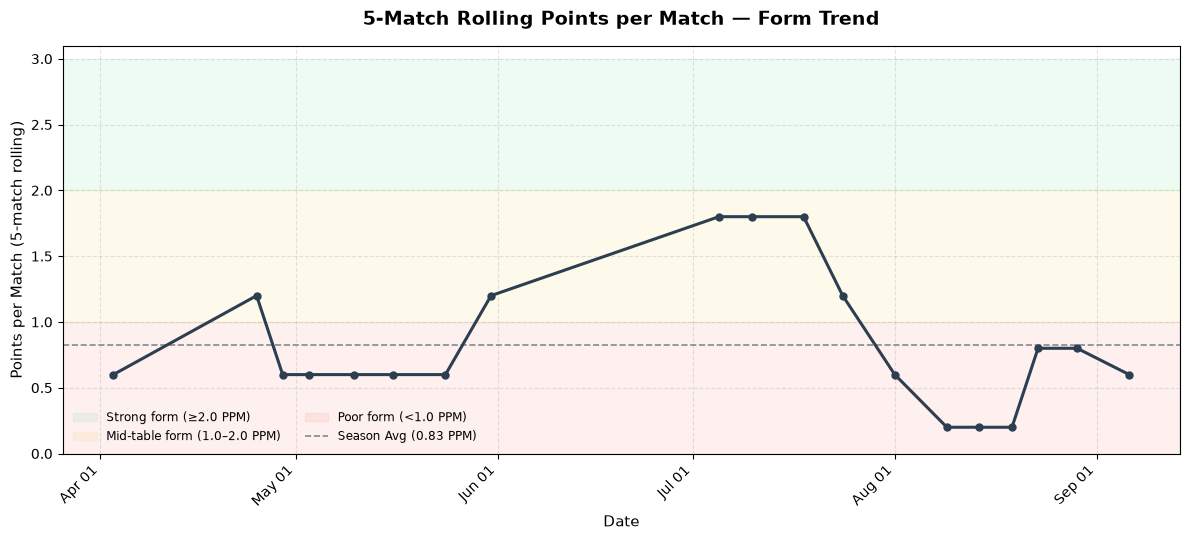

In [39]:


df = df.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 5.5))

# Shaded form zones for context (based on PPM benchmarks)
ax.axhspan(2.0, 3.0, color="#2ecc71", alpha=0.08, label="Strong form (≥2.0 PPM)")
ax.axhspan(1.0, 2.0, color="#f1c40f", alpha=0.08, label="Mid-table form (1.0–2.0 PPM)")
ax.axhspan(0.0, 1.0, color="#e74c3c", alpha=0.08, label="Poor form (<1.0 PPM)")

# Main rolling PPM line
ax.plot(df["Date"], df["Rolling_PPM_5"],
        marker="o", markersize=5, linewidth=2.2,
        color="#2c3e50", zorder=5)

# Reference line: overall season average PPM
season_avg = df["Points"].mean() if "Points" in df.columns else df["Rolling_PPM_5"].mean()
ax.axhline(season_avg, color="#7f8c8d", linestyle="--", linewidth=1.2,
           label=f"Season Avg ({season_avg:.2f} PPM)")

# Annotate current (latest) form
last_date = df["Date"].iloc[-1]
last_val = df["Rolling_PPM_5"].iloc[-1]
ax.annotate(f"{last_val:.2f}",
            xy=(last_date, last_val),
            xytext=(10, 5), textcoords="offset points",
            fontsize=10, fontweight="bold", color="#2c3e50")

# Date formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Points per Match (5-match rolling)", fontsize=11)
ax.set_title("5-Match Rolling Points per Match — Form Trend", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, 3.1)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=2)

plt.tight_layout()
plt.show()

In [40]:
df["Goal_Difference"] = df["GF"] - df["GA"]

df["Rolling_GF"] = df["GF"].rolling(5).mean()
df["Rolling_GA"] = df["GA"].rolling(5).mean()

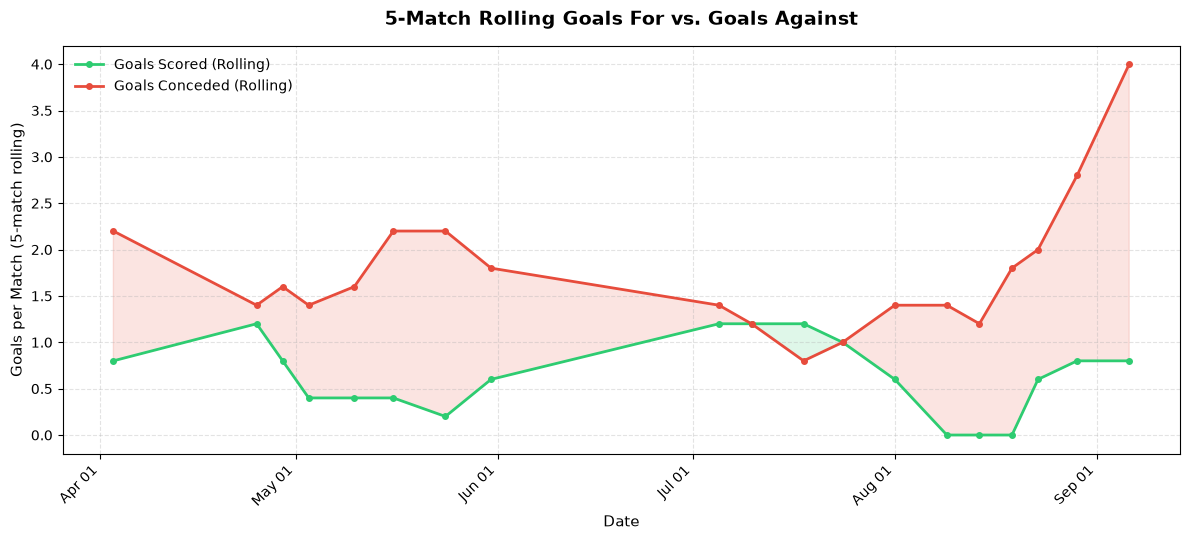

In [41]:


df = df.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 5.5))

# Main rolling lines
ax.plot(df["Date"], df["Rolling_GF"], marker="o", markersize=4,
        linewidth=2, color="#2ecc71", label="Goals Scored (Rolling)")
ax.plot(df["Date"], df["Rolling_GA"], marker="o", markersize=4,
        linewidth=2, color="#e74c3c", label="Goals Conceded (Rolling)")

# Shade the gap: green when scoring > conceding, red when the reverse
ax.fill_between(df["Date"], df["Rolling_GF"], df["Rolling_GA"],
                where=(df["Rolling_GF"] >= df["Rolling_GA"]),
                interpolate=True, color="#2ecc71", alpha=0.15)
ax.fill_between(df["Date"], df["Rolling_GF"], df["Rolling_GA"],
                where=(df["Rolling_GF"] < df["Rolling_GA"]),
                interpolate=True, color="#e74c3c", alpha=0.15)

# Annotate latest values
last_date = df["Date"].iloc[-1]
last_gf = df["Rolling_GF"].iloc[-1]
last_ga = df["Rolling_GA"].iloc[-1]
ax.annotate(f"{last_gf:.2f}", xy=(last_date, last_gf), xytext=(10, 0),
            textcoords="offset points", fontsize=9, fontweight="bold", color="#2ecc71")
ax.annotate(f"{last_ga:.2f}", xy=(last_date, last_ga), xytext=(10, 0),
            textcoords="offset points", fontsize=9, fontweight="bold", color="#e74c3c")

# Date formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Goals per Match (5-match rolling)", fontsize=11)
ax.set_title("5-Match Rolling Goals For vs. Goals Against", fontsize=14, fontweight="bold", pad=15)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [42]:
df["Rolling_Possession"] = df["Poss"].rolling(5).mean()

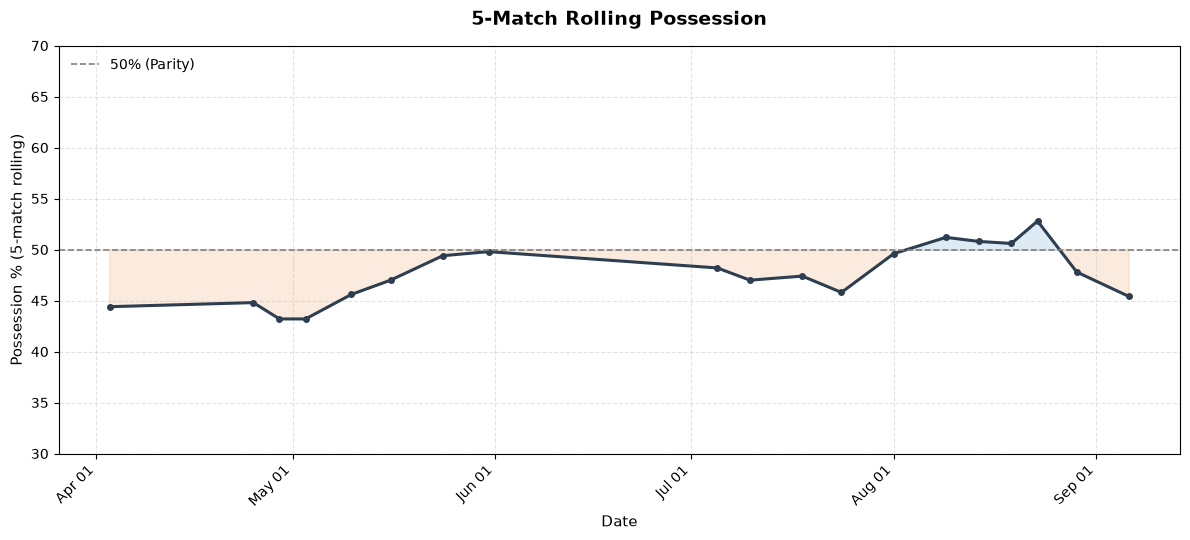

In [43]:

fig, ax = plt.subplots(figsize=(12, 5.5))

# Shade above/below 50% for quick read
ax.fill_between(df["Date"], df["Rolling_Possession"], 50,
                where=(df["Rolling_Possession"] >= 50),
                interpolate=True, color="#2c7fb8", alpha=0.15)
ax.fill_between(df["Date"], df["Rolling_Possession"], 50,
                where=(df["Rolling_Possession"] < 50),
                interpolate=True, color="#e67e22", alpha=0.15)

# Main line
ax.plot(df["Date"], df["Rolling_Possession"],
        marker="o", markersize=4, linewidth=2.2, color="#2c3e50")

# 50% reference line
ax.axhline(50, color="gray", linestyle="--", linewidth=1.2, label="50% (Parity)")

# Annotate latest value
last_date = df["Date"].iloc[-1]
last_val = df["Rolling_Possession"].iloc[-1]
ax.annotate(f"{last_val:.1f}%", xy=(last_date, last_val), xytext=(10, 0),
            textcoords="offset points", fontsize=10, fontweight="bold", color="#2c3e50")

# Date formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Possession % (5-match rolling)", fontsize=11)
ax.set_title("5-Match Rolling Possession", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(min(30, df["Rolling_Possession"].min() - 5), max(70, df["Rolling_Possession"].max() + 5))
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()